In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from PyEMD import EMD  # pip install PyEMD


# STL-based DATC

In [ ]:
def estimate_period_fft(series, period=24):
    """
    FFT를 활용하여 시계열 데이터에서 가장 지배적인 주기를 동적으로 추정합니다.
    """
    n = len(series)
    t = np.arange(n)
    
    # 1. FFT 전처리: 선형 추세 및 평균(DC 성분) 제거
    p = np.polyfit(t, series, 1)
    detrended = series - np.polyval(p, t)
    detrended = detrended - np.mean(detrended)
    
    # 2. FFT 수행 및 진폭 계산
    fft_vals = np.fft.rfft(detrended)
    frequencies = np.fft.rfftfreq(n)
    magnitudes = np.abs(fft_vals)
    
    # 3. 0Hz(상수항)를 제외하고 진폭이 가장 큰 인덱스 탐색
    if len(magnitudes) > 1:
        dominant_idx = np.argmax(magnitudes[1:]) + 1 
        dominant_freq = frequencies[dominant_idx]
        
        if dominant_freq > 0:
            period = int(np.round(1.0 / dominant_freq))
            if 2 <= period <= n // 2:
                return period
                
    return period

def calculate_time_series_strength(series, dec_method='stl_emd'):
    """
    FFT 기반 동적 주기 추출 후, 지정된 분해 방법론(dec_method)에 따라
    독립적 신호 대 잡음비(SNR) 기반의 F_T, F_S, F_I 지표를 산출합니다.
    
    Parameters:
    - series: 입력 시계열 데이터 (1D array-like)
    - dec_method: 'stl' (고전 STL 분해) 또는 'stl_emd' (STL-EMD 결합 분해)
    """
    estimated_p = estimate_period_fft(series)
    
    if len(series) < 2 * estimated_p:
        estimated_p = max(2, len(series) // 2 - 1)
        
    try:
        # 1. 공통 단계: STL 분해 (T, S, R_stl 도출)
        res = STL(series, period=estimated_p, robust=True).fit()
        T, S, R_stl = res.trend, res.seasonal, res.resid
        
        # 2. 분해 기법(dec_method)에 따른 분기 처리
        if dec_method == 'stl_emd':
            # EMD 분해 (Residual을 다시 분해하여 Intervention 추출)
            emd = EMD()
            imfs = emd.emd(R_stl)
            
            # IMF 성분 중 노이즈(IMF1)와 최저주파 잔차를 제외한 중간 대역을 I(Intervention)로 정의
            if len(imfs) > 2:
                I = np.sum(imfs[1:-1], axis=0) 
            elif len(imfs) == 2:
                I = imfs[1]
            else:
                I = np.zeros_like(R_stl)
                
            # 순수 노이즈(R_pure) = STL 잔차에서 개입 성분(I)을 제거한 청정 구역
            R_pure = R_stl - I
            
        elif dec_method == 'stl':
            # 고전적 STL: 개입 성분이 존재하지 않음 (I = 0)
            I = np.zeros_like(R_stl)
            # STL의 잔차가 곧 순수 노이즈로 간주됨
            R_pure = R_stl
            
        else:
            raise ValueError(f"Unknown dec_method: {dec_method}. Choose 'stl' or 'stl_emd'.")
            
        # 3. Hyndman 공리 기반의 성분별 직교(Orthogonal) 강도 계산
        var_R = np.var(R_pure)
        var_TR = np.var(T + R_pure) 
        var_SR = np.var(S + R_pure)
        var_IR = np.var(I + R_pure) 
        
        F_T = max(0.0, 1.0 - (var_R / var_TR if var_TR > 0 else 1.0))
        F_S = max(0.0, 1.0 - (var_R / var_SR if var_SR > 0 else 1.0))
        
        # dec_method='stl'일 경우 var_R == var_IR이 되므로 수리적으로 F_I는 자연스럽게 0.0이 됨
        F_I = max(0.0, 1.0 - (var_R / var_IR if var_IR > 0 else 1.0))
        
    except Exception:
        # 분해 실패 시 예외 처리 (정상성 노이즈로 간주)
        F_T, F_S, F_I = 0.0, 0.0, 0.0
        
    return F_T, F_S, F_I, estimated_p

def generate_synthetic_dataset(num_samples_per_regime=50, len_series=500, dec_method='stl'):
    """
    4사분면 검증을 위해 통계적 특성이 다양한 복잡한 가상 시계열 데이터를 대량 생성합니다.
    """
    print(f"🔹 Generating synthetic dataset with {num_samples_per_regime} samples per regime, each of length {len_series} with {dec_method} method")

    data_records = []
    t = np.arange(len_series)
    
    for i in range(num_samples_per_regime):
        print(f"💡 Generating sample {i+1}/{num_samples_per_regime} for each regime...")
        
        rand_p1 = np.random.choice([12, 24, 36, 48])
        rand_p2 = rand_p1 * 2
        
        # --- R1: Composite Regime ---
        slope = np.random.uniform(0.1, 0.4) * np.random.choice([1, -1])
        curve = np.random.uniform(1e-5, 5e-5) * np.random.choice([1, -1])
        amp1, amp2 = np.random.uniform(8, 25), np.random.uniform(2, 8)
        noise_std = np.random.uniform(0.5, 1.5)
        
        q1_series = (slope * t + curve * (t**2)) + (amp1 * np.sin(2 * np.pi * t / rand_p1)) + (amp2 * np.cos(2 * np.pi * t / rand_p2)) + np.random.normal(0, noise_std, len_series)
        q1_scaled = (q1_series - np.min(q1_series)) / (np.max(q1_series) - np.min(q1_series) + 1e-9)
        ft, fs, fi, p_est = calculate_time_series_strength(q1_scaled, dec_method)
        

        data_records.append({
            'True_Regime': 'R1', 'Pattern': 'Composite', 'F_T': ft, 'F_S': fs, 'F_I': fi, 'True_P': rand_p1, 'Est_P': p_est,
            'rand_p1': rand_p1, 'rand_p2': rand_p2, 'length': len_series, 'slope': slope, 'curve': curve, # 단일 상숫값으로 안전하게 독립 컬럼 저장!
            'amp1': amp1, 'amp2': amp2, 'noise_std': noise_std,
            'phi': None, 'break_point': None, 'drift': None
        })
        
        # --- R2: Pure Seasonal ---
        amp1, amp2 = np.random.uniform(10, 30), np.random.uniform(4, 12)
        noise_std = np.random.uniform(0.5, 2.0)
        
        q2_series = (amp1 * np.sin(2 * np.pi * t / rand_p1)) + (amp2 * np.cos(2 * np.pi * t / rand_p2)) + np.random.normal(0, noise_std, len_series)
        q2_scaled = (q2_series - np.min(q2_series)) / (np.max(q2_series) - np.min(q2_series) + 1e-9)
        ft, fs, fi, p_est = calculate_time_series_strength(q2_scaled, dec_method)
        

        data_records.append({
            'True_Regime': 'R2', 'Pattern': 'Seasonal', 'F_T': ft, 'F_S': fs, 'F_I': fi, 'True_P': rand_p1, 'Est_P': p_est,
            'rand_p1': rand_p1, 'rand_p2': rand_p2, 'length': len_series, 'slope': 0.0, 'curve': 0.0,
            'amp1': amp1, 'amp2': amp2, 'noise_std': noise_std,
            'phi': None, 'break_point': None, 'drift': None
        })

        # --- R3: Stationary / Noise ---
        noise_type = np.random.choice(['WN', 'AR'])
        phi_val = None
        
        if noise_type == 'WN':
            noise_std_wn = np.random.uniform(5, 15)
            q3_series = np.random.normal(0, noise_std_wn, len_series)
            current_noise_std = noise_std_wn
        else:
            phi_val = np.random.uniform(0.4, 0.7)
            q3_series = np.zeros(len_series)
            innovations_std = 5.0
            innovations = np.random.normal(0, innovations_std, len_series)
            q3_series[0] = innovations[0]
            for idx in range(1, len_series):
                q3_series[idx] = phi_val * q3_series[idx-1] + innovations[idx]
            current_noise_std = innovations_std

        q3_scaled = (q3_series - np.min(q3_series)) / (np.max(q3_series) - np.min(q3_series) + 1e-9)
        ft, fs, fi, p_est = calculate_time_series_strength(q3_scaled, dec_method)
        
        data_records.append({'True_Regime': 'R3', 'Pattern': f'Stationary_{noise_type}', 'F_T': ft, 'F_S': fs, 'F_I': fi, 'True_P': 'None', 'Est_P': p_est})

        data_records.append({
            'True_Regime': 'R3', 'Pattern': f'Stationary_{noise_type}', 'F_T': ft, 'F_S': fs, 'F_I': fi, 'True_P': 'None', 'Est_P': p_est,
            'rand_p1': None, 'rand_p2': None, 'length': len_series, 'slope': 0.0, 'curve': 0.0, 
            'amp1': 0.0, 'amp2': 0.0, 'noise_std': current_noise_std,
            'phi': phi_val, 'break_point': None, 'drift': None
        })


        # --- R4: Pure Trending (with Structural Breaks & Drifts) ---
        trend_type = np.random.choice(['MeanShift', 'RandomWalkDrift', 'ExponentialGrowth'])
        noise_std = np.random.uniform(0.5, 1.5)
        
        bp_val = None
        drift_val = None
        
        if trend_type == 'MeanShift':
            bp_val = len_series // 2
            q4_series = np.random.normal(0, noise_std, len_series)
            q4_series[bp_val:] += np.random.uniform(50, 150)
        elif trend_type == 'RandomWalkDrift':
            drift_val = np.random.uniform(0.1, 0.5) * np.random.choice([1, -1])
            q4_series = np.cumsum(np.random.normal(drift_val, 2, len_series))
        else:
            q4_series = np.exp(np.linspace(0, np.random.uniform(3, 5), len_series)) + np.random.normal(0, noise_std, len_series)

        q4_scaled = (q4_series - np.min(q4_series)) / (np.max(q4_series) - np.min(q4_series) + 1e-9)
        ft, fs, fi, p_est = calculate_time_series_strength(q4_scaled, dec_method)

        if trend_type == 'ExponentialGrowth':
            print(f'ExponentialGrowth series generated. Estimated period: {p_est}, F_T: {ft:.4f}, F_S: {fs:.4f}, F_I: {fi:.4f}')
        
        data_records.append({'True_Regime': 'R4', 'Pattern': f'Trending_{trend_type}', 'F_T': ft, 'F_S': fs, 'F_I': fi, 'True_P': 'None', 'Est_P': p_est})

        data_records.append({
            'True_Regime': 'R4', 'Pattern': f'Trending_{trend_type}', 'F_T': ft, 'F_S': fs, 'F_I': fi, 'True_P': 'None', 'Est_P': p_est,
            'rand_p1': None, 'rand_p2': None, 'length': len_series, 'slope': None, 'curve': None, 
            'amp1': 0.0, 'amp2': 0.0, 'noise_std': noise_std,
            'phi': None, 'break_point': bp_val, 'drift': drift_val
        })
        
    return pd.DataFrame(data_records)


In [53]:
df_exp_results = generate_synthetic_dataset(num_samples_per_regime=50, len_series=500, dec_method='stl')
#df_exp_results.to_csv('../../results/temp/0706_Per1000_Len500_Stl_synthetic_dataset.csv', index=False)

🔹 Generating synthetic dataset with 50 samples per regime, each of length 500 with stl method
💡 Generating sample 1/50 for each regime...
💡 Generating sample 2/50 for each regime...
ExponentialGrowth series generated. Estimated period: 249, F_T: 1.0000, F_S: 0.9999, F_I: 0.0000
💡 Generating sample 3/50 for each regime...
ExponentialGrowth series generated. Estimated period: 249, F_T: 1.0000, F_S: 0.9999, F_I: 0.0000
💡 Generating sample 4/50 for each regime...
💡 Generating sample 5/50 for each regime...
💡 Generating sample 6/50 for each regime...


KeyboardInterrupt: 

In [49]:
df_exp_results[df_exp_results['Pattern'].str.contains('Trending')].head(10)

,True_Regime,Pattern,F_T,F_S,F_I,True_P,Est_P,rand_p1,rand_p2,length,slope,curve,amp1,amp2,noise_std,phi,break_point,drift
4,R4,Trending_RandomWalkDrift,0.999999,0.999989,0.0,None,249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,R4,Trending_RandomWalkDrift,0.999999,0.999989,0.0,None,249,NaN,NaN,500.0,NaN,NaN,0.0,0.0,1.082624,NaN,NaN,-0.482197
10,R4,Trending_ExponentialGrowth,0.999965,0.999894,0.0,None,249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,R4,Trending_ExponentialGrowth,0.999965,0.999894,0.0,None,249,NaN,NaN,500.0,NaN,NaN,0.0,0.0,1.348041,NaN,NaN,NaN
16,R4,Trending_MeanShift,0.999899,0.999598,0.0,None,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,R4,Trending_MeanShift,0.999899,0.999598,0.0,None,250,NaN,NaN,500.0,NaN,NaN,0.0,0.0,1.207587,NaN,250.0,NaN
22,R4,Trending_MeanShift,0.999984,0.999934,0.0,None,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,R4,Trending_MeanShift,0.999984,0.999934,0.0,None,250,NaN,NaN,500.0,NaN,NaN,0.0,0.0,0.925969,NaN,250.0,NaN
28,R4,Trending_ExponentialGrowth,0.999963,0.999893,0.0,None,249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29,R4,Trending_ExponentialGrowth,0.999963,0.999893,0.0,None,249,NaN,NaN,500.0,NaN,NaN,0.0,0.0,1.005383,NaN,NaN,NaN


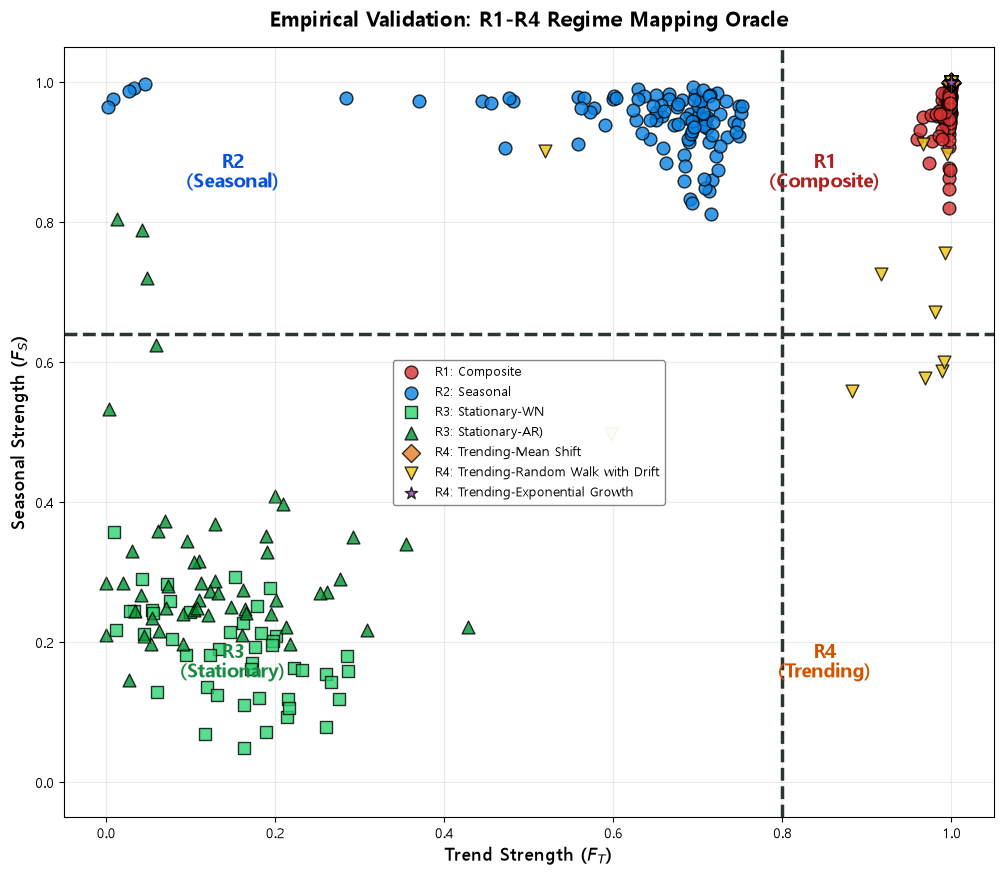


     [오라클 검증 통계 리포트 (임계치: 0.64)]
▶ R1: Composite Regime
  - 생성 패턴 예시: <ArrowStringArray>['Composite']Length: 1, dtype: str
  - 평균 지표값  : Mean F_T = 0.994 | Mean F_S = 0.957
  - FFT 주기 추정 정확도: 77.0%
  - 사분면 매핑 성공률 : [ 100 / 100 ] (100.0%)
------------------------------------------------------------
▶ R2: Seasonal Regime
  - 생성 패턴 예시: <ArrowStringArray>['Seasonal']Length: 1, dtype: str
  - 평균 지표값  : Mean F_T = 0.630 | Mean F_S = 0.944
  - FFT 주기 추정 정확도: 75.0%
  - 사분면 매핑 성공률 : [ 100 / 100 ] (100.0%)
------------------------------------------------------------
▶ R3: Stationary Regime
  - 생성 패턴 예시: <ArrowStringArray>['Stationary_AR', 'Stationary_WN']Length: 2, dtype: str
  - 평균 지표값  : Mean F_T = 0.139 | Mean F_S = 0.254
  - 사분면 매핑 성공률 : [ 97 / 100 ] (97.0%)
------------------------------------------------------------
▶ R4: Trending Regime
  - 생성 패턴 예시: <ArrowStringArray>['Trending_RandomWalkDrift', 'Trending_ExponentialGrowth', 'Trending_MeanShift']Length: 3, dtype: str
  - 평균 지표값  : Mean 

In [34]:
# ==========================================
# 2. 결과 시각화 (R1~R4 범례 순서 고정 및 세부 패턴 플롯팅)
# ==========================================
F_T_thr = 0.80
F_S_thr = 0.64

plt.figure(figsize=(12, 10))

# 1. 학술적 일관성을 위해 패턴별 고유 시각 세팅 테이블 정의
pattern_configs = {
    'Composite':                    {'color': '#d63031', 'marker': 'o', 'label': 'R1: Composite'},
    'Seasonal':                     {'color': '#0984e3', 'marker': 'o', 'label': 'R2: Seasonal'},
    'Stationary_WN':                {'color': '#2ed573', 'marker': 's', 'label': 'R3: Stationary-WN'},
    'Stationary_AR':                {'color': '#009432', 'marker': '^', 'label': 'R3: Stationary-AR)'},
    'Trending_MeanShift':           {'color': '#e67e22', 'marker': 'D', 'label': 'R4: Trending-Mean Shift'},
    'Trending_RandomWalkDrift':     {'color': '#f1c40f', 'marker': 'v', 'label': 'R4: Trending-Random Walk with Drift'},
    'Trending_ExponentialGrowth':   {'color': '#8e44ad', 'marker': '*', 'label': 'R4: Trending-Exponential Growth'}
}

# 2. 범례 순서를 R1 -> R2 -> R3 -> R4 순으로 강제 정렬하기 위한 마스터 맵 순서 선언
legend_order = [
    'Composite',
    'Seasonal',
    'Stationary_WN',
    'Stationary_AR',
    'Trending_MeanShift',
    'Trending_RandomWalkDrift',
    'Trending_ExponentialGrowth'
]

# 3. 데이터프레임 내에 존재하는 패턴만 필터링하여 순서대로 플롯팅 (범례 순서 꼬임 원천 차단)
existing_patterns = [p for p in legend_order if p in df_exp_results['Pattern'].unique()]

for pattern_label in existing_patterns:
    group = df_exp_results[df_exp_results['Pattern'] == pattern_label]
    config = pattern_configs.get(pattern_label, {'color': '#7f8c8d', 'marker': 'x', 'label': pattern_label})
    
    plt.scatter(group['F_T'], group['F_S'], 
                label=config['label'], color=config['color'], marker=config['marker'],
                alpha=0.8, edgecolors='k', s=85)

# 오라클 결정 가이드라인 경계선 (tau = 0.64)
plt.axvline(x=F_T_thr, color='#2d3436', linestyle='--', linewidth=2.5)
plt.axhline(y=F_S_thr, color='#2d3436', linestyle='--', linewidth=2.5)

# 사분면 텍스트 표기
plt.text(0.85, 0.85, 'R1\n(Composite)', fontsize=14, fontweight='bold', ha='center', color='#b21f1f')
plt.text(0.15, 0.85, 'R2\n(Seasonal)', fontsize=14, fontweight='bold', ha='center', color='#0652dd')
plt.text(0.15, 0.15, 'R3\n(Stationary)', fontsize=14, fontweight='bold', ha='center', color='#1b8a43')
plt.text(0.85, 0.15, 'R4\n(Trending)', fontsize=14, fontweight='bold', ha='center', color='#d35400')

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.xlabel('Trend Strength ($F_T$)', fontsize=13, fontweight='bold')
plt.ylabel('Seasonal Strength ($F_S$)', fontsize=13, fontweight='bold')
plt.title('Empirical Validation: R1-R4 Regime Mapping Oracle', fontsize=15, fontweight='bold', pad=15)

# 범례 정중앙 위치 설정 (가독성을 위한 반투명 흰색 배경막 장착)
plt.legend(loc='center', fontsize=9.5, framealpha=0.95, facecolor='white', edgecolor='gray')
plt.grid(True, alpha=0.25)
plt.show()

# ==========================================
# 3. 오라클 분류 정확도 결산 리포트 출력
# ==========================================
print("\n" + "="*60)
print("     [오라클 검증 통계 리포트 (임계치: 0.64)]")
print("="*60)

regime_names = {'R1': 'Composite Regime', 'R2': 'Seasonal Regime', 'R3': 'Stationary Regime', 'R4': 'Trending Regime'}

total_success = 0
# 데이터셋 내의 고유 레짐 라벨을 기준으로 루프 실행
for r_label in ['R1', 'R2', 'R3', 'R4']:
    sub_df = df_exp_results[df_exp_results['True_Regime'] == r_label]
    
    # 사분면 조건문 (R1~R4 로직 반영)
    if r_label == 'R1':
        success_condition = (sub_df['F_T'] >= F_T_thr) & (sub_df['F_S'] >= F_S_thr)
    elif r_label == 'R2':
        success_condition = (sub_df['F_T'] < F_T_thr) & (sub_df['F_S'] >= F_S_thr)
    elif r_label == 'R3':
        success_condition = (sub_df['F_T'] < F_T_thr) & (sub_df['F_S'] < F_S_thr)
    elif r_label == 'R4':
        success_condition = (sub_df['F_T'] >= F_T_thr) & (sub_df['F_S'] < F_S_thr)
        
    success_count = len(sub_df[success_condition])
    total_success += success_count
    accuracy = (success_count / len(sub_df)) * 100
    
    unique_patterns = list(sub_df['Pattern'].unique())
    print(f"▶ {r_label}: {regime_names[r_label]}")
    print(f"  - 생성 패턴 예시: <ArrowStringArray>{unique_patterns}Length: {len(unique_patterns)}, dtype: str")
    print(f"  - 평균 지표값  : Mean F_T = {sub_df['F_T'].mean():.3f} | Mean F_S = {sub_df['F_S'].mean():.3f}")
    
    # 주기 매칭 검증 (R1, R2에 대해서만 추출 성과 체크)
    if r_label in ['R1', 'R2']:
        same_p_count = len(sub_df[sub_df['True_P'] == sub_df['Est_P']])
        p_match_rate = (same_p_count / len(sub_df)) * 100
        print(f"  - FFT 주기 추정 정확도: {p_match_rate:.1f}%")
        
    print(f"  - 사분면 매핑 성공률 : [ {success_count} / {len(sub_df)} ] ({accuracy:.1f}%)")
    print("-" * 60)

print(f"■ 전체 통합 오라클 라우팅 정확도: {(total_success / len(df_exp_results))*100:.2f}%")
print("="*60)

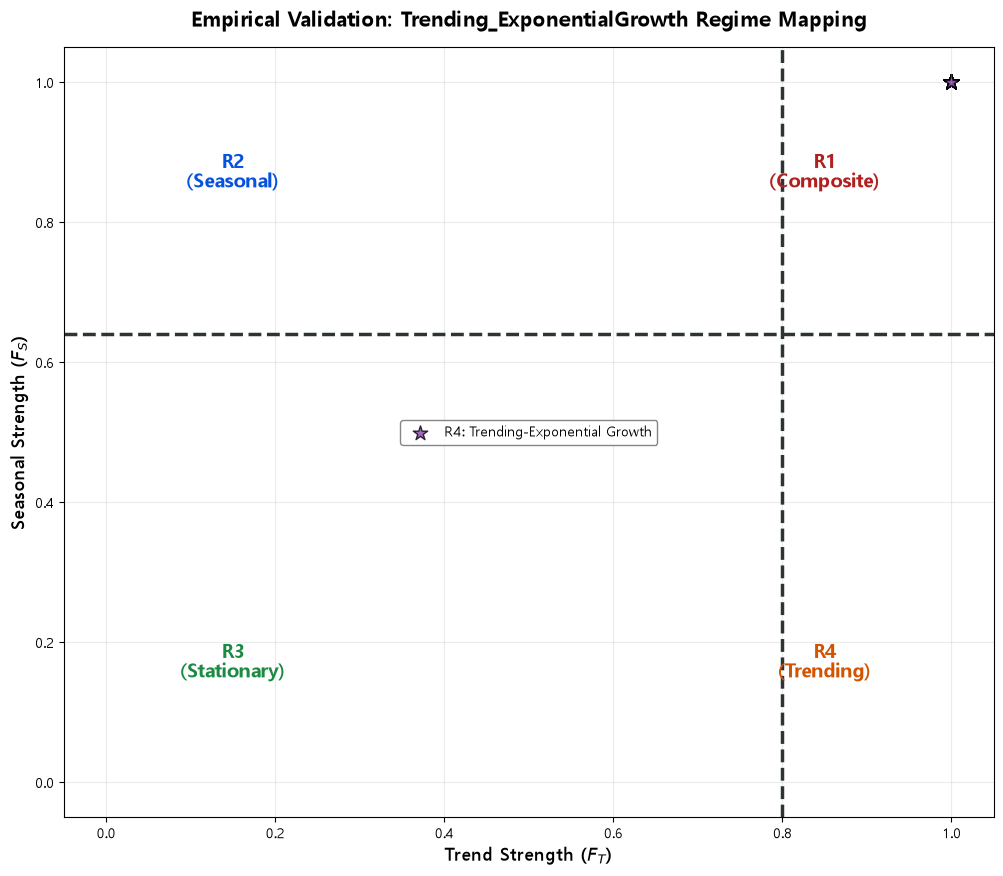

In [35]:
import matplotlib.pyplot as plt

# ==========================================
# 2. 결과 시각화 (Trending_ExponentialGrowth 단독 플롯팅)
# ==========================================
F_T_thr = 0.80
F_S_thr = 0.64

plt.figure(figsize=(12, 10))

# 1. 'Trending_ExponentialGrowth' 단독 설정 정의
target_pattern = 'Trending_ExponentialGrowth'
config = {'color': '#8e44ad', 'marker': '*', 'label': 'R4: Trending-Exponential Growth'}

# 2. 데이터프레임 내에 해당 패턴이 존재하는지 확인 후 단독 플롯팅
if target_pattern in df_exp_results['Pattern'].unique():
    group = df_exp_results[df_exp_results['Pattern'] == target_pattern]
    
    plt.scatter(group['F_T'], group['F_S'],
                label=config['label'], color=config['color'], marker=config['marker'],
                alpha=0.8, edgecolors='k', s=120)  # 단독 시각화이므로 가독성을 위해 마커 크기(s)를 살짝 키웠습니다.

# 오라클 결정 가이드라인 경계선 (임계치 시각화)
plt.axvline(x=F_T_thr, color='#2d3436', linestyle='--', linewidth=2.5)
plt.axhline(y=F_S_thr, color='#2d3436', linestyle='--', linewidth=2.5)

# 사분면 텍스트 표기
plt.text(0.85, 0.85, 'R1\n(Composite)', fontsize=14, fontweight='bold', ha='center', color='#b21f1f')
plt.text(0.15, 0.85, 'R2\n(Seasonal)', fontsize=14, fontweight='bold', ha='center', color='#0652dd')
plt.text(0.15, 0.15, 'R3\n(Stationary)', fontsize=14, fontweight='bold', ha='center', color='#1b8a43')
plt.text(0.85, 0.15, 'R4\n(Trending)', fontsize=14, fontweight='bold', ha='center', color='#d35400')

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.xlabel('Trend Strength ($F_T$)', fontsize=13, fontweight='bold')
plt.ylabel('Seasonal Strength ($F_S$)', fontsize=13, fontweight='bold')
plt.title('Empirical Validation: Trending_ExponentialGrowth Regime Mapping', fontsize=15, fontweight='bold', pad=15)

# 범례 및 그리드 설정
plt.legend(loc='center', fontsize=10, framealpha=0.95, facecolor='white', edgecolor='gray')
plt.grid(True, alpha=0.25)
plt.show()

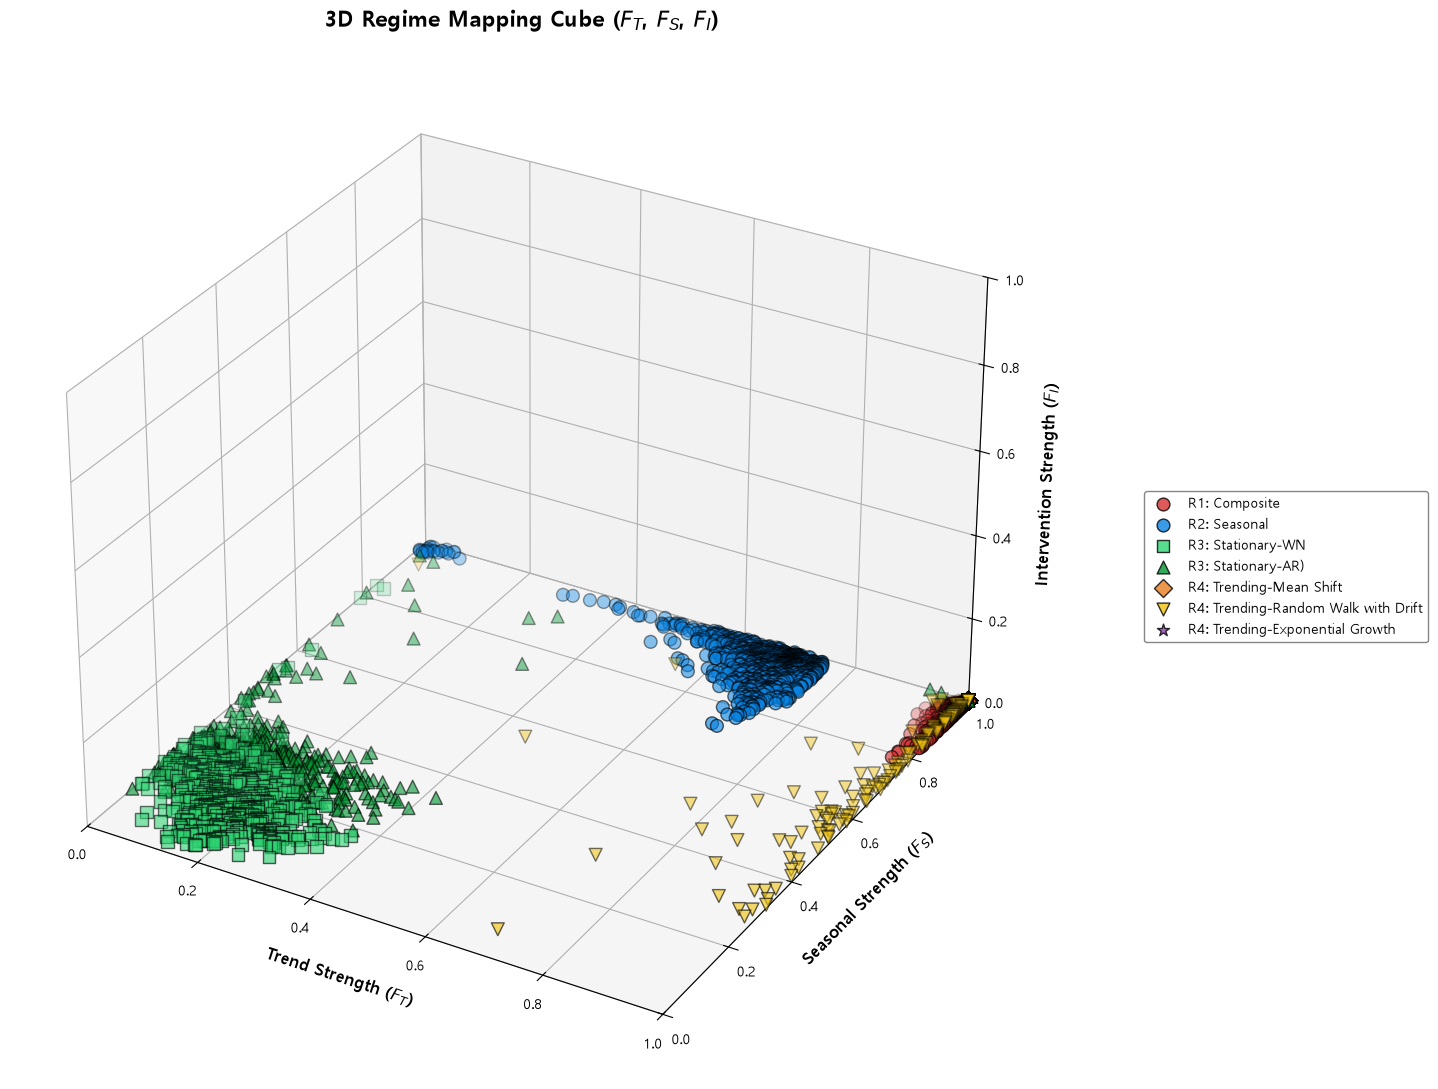


     [오라클 검증 통계 리포트 (3D 확장판 - 직교성 반영)]
▶ R1 Regime 평균 지표값
   F_T: 0.994 | F_S: 0.957 | F_I: 0.000
▶ R2 Regime 평균 지표값
   F_T: 0.656 | F_S: 0.941 | F_I: 0.000
▶ R3 Regime 평균 지표값
   F_T: 0.144 | F_S: 0.243 | F_I: 0.000
▶ R4 Regime 평균 지표값
   F_T: 0.994 | F_S: 0.963 | F_I: 0.000
   -> (R4 내부 상세 F_I 분석)
      Trending_MeanShift: F_I = 0.000
      Trending_ExponentialGrowth: F_I = 0.000
      Trending_RandomWalkDrift: F_I = 0.000


In [29]:
# ==========================================
# 2. 결과 시각화 (3D Cube Mapping)
# ==========================================
plt.rcParams['font.family'] = 'Malgun Gothic' # 환경에 따라 'AppleGothic' 등으로 변경 필요
plt.rcParams['axes.unicode_minus'] = False

fig = plt.figure(figsize=(14, 11))
ax = fig.add_subplot(111, projection='3d')

# 패턴별 색상 및 마커
pattern_configs = {
    'Composite':                    {'color': '#d63031', 'marker': 'o', 'label': 'R1: Composite'},
    'Seasonal':                     {'color': '#0984e3', 'marker': 'o', 'label': 'R2: Seasonal'},
    'Stationary_WN':                {'color': '#2ed573', 'marker': 's', 'label': 'R3: Stationary-WN'},
    'Stationary_AR':                {'color': '#009432', 'marker': '^', 'label': 'R3: Stationary-AR)'},
    'Trending_MeanShift':           {'color': '#e67e22', 'marker': 'D', 'label': 'R4: Trending-Mean Shift'},
    'Trending_RandomWalkDrift':     {'color': '#f1c40f', 'marker': 'v', 'label': 'R4: Trending-Random Walk with Drift'},
    'Trending_ExponentialGrowth':   {'color': '#8e44ad', 'marker': '*', 'label': 'R4: Trending-Exponential Growth'}
}

legend_order = list(pattern_configs.keys())
existing_patterns = [p for p in legend_order if p in df_exp_results['Pattern'].unique()]

# 3D 산점도 플로팅
for pattern_label in existing_patterns:
    group = df_exp_results[df_exp_results['Pattern'] == pattern_label]
    config = pattern_configs[pattern_label]
    
    ax.scatter(group['F_T'], group['F_S'], group['F_I'], 
               label=config['label'], color=config['color'], marker=config['marker'],
               alpha=0.8, edgecolors='k', s=85)

# 축 레이블 및 세팅
ax.set_xlabel('Trend Strength ($F_T$)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Seasonal Strength ($F_S$)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_zlabel('Intervention Strength ($F_I$)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_zlim(0, 1)
ax.set_title('3D Regime Mapping Cube ($F_T$, $F_S$, $F_I$)', fontsize=16, fontweight='bold', pad=20)

# 범례 설정 (그래프 바깥쪽)
ax.legend(loc='center left', bbox_to_anchor=(1.1, 0.5), fontsize=10, framealpha=0.95, facecolor='white', edgecolor='gray')

plt.tight_layout()
plt.show()

# ==========================================
# 3. 간단한 리포트 (F_I 지표 평균 확인용)
# ==========================================
print("\n" + "="*60)
print("     [오라클 검증 통계 리포트 (3D 확장판 - 직교성 반영)]")
print("="*60)
for r_label in ['R1', 'R2', 'R3', 'R4']:
    sub_df = df_exp_results[df_exp_results['True_Regime'] == r_label]
    print(f"▶ {r_label} Regime 평균 지표값")
    print(f"   F_T: {sub_df['F_T'].mean():.3f} | F_S: {sub_df['F_S'].mean():.3f} | F_I: {sub_df['F_I'].mean():.3f}")
    if r_label == 'R4':
        print("   -> (R4 내부 상세 F_I 분석)")
        for p in sub_df['Pattern'].unique():
            p_df = sub_df[sub_df['Pattern'] == p]
            print(f"      {p}: F_I = {p_df['F_I'].mean():.3f}")
print("="*60)

# STL-EMD based DATC

In [ ]:
df_exp_results = generate_synthetic_dataset(num_samples_per_regime=1000, len_series=500, dec_method='stl_emd')
df_exp_results.to_csv('../../results/temp/0706_Per1000_Len500_StlEmd_synthetic_dataset.csv', index=False)